#**Project Title**
## Seasonal Agriculture Performance Analysis

###**Objective**
Objective of this project is to analyze agricultural data from different seasons
and identify meaningful patterns, trends, relationships and differences in agricultural
performance.

### **Dataset**
Seasonal Agriculture Performance Dataset

##**Introduction**
Every harvest depends heavily on the time of year, changing weather, and shifting market costs.

This analysis examines field data across various regions and crop types to map out these seasonal patterns.

The main goal is to show exactly how environmental shifts and resource management directly shape both crop growth and a farm's financial bottom line.

##**Problem Statement**

Looking at raw farm data doesn't automatically show us how agricultural success shifts from season to season.

Because of this, the project aims to dive into the data to uncover:

* How crop performance changes between different seasons.
* The main patterns and trends that come up throughout the year.
* How local weather and environmental factors directly impact harvests.
* Shifts in how water, fertilizer, and other resources are used over time.
* The way a farm's financial returns fluctuate depending on the season.
* Any surprising or unexpected data points that break the usual trends.

#**1. Import Libraries**

In [5]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


#**2. Load Dataset**

In [6]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')


#**3. Check that the dataset loaded**

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


#**4. Top 5 rows**

In [8]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


#**5. Bottom 5 rows**

In [9]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


#**6. Dataset Shape**

In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4000, 28)


#**7. Dataset Information**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

#**8. Data Types**

In [12]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


#**9. Dataset Columns**

In [13]:
print("Total columns:", len(df.columns))

for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Total columns: 28
1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


#**10. Missing value analysis**

In [14]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns containing missing values:")
display(missing_values)

Columns containing missing values:


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


#**11. Missing-value percentage**

In [15]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_table = missing_table[missing_table['Missing Values'] > 0]

display(missing_table)

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


#**12. Visualize missing values**

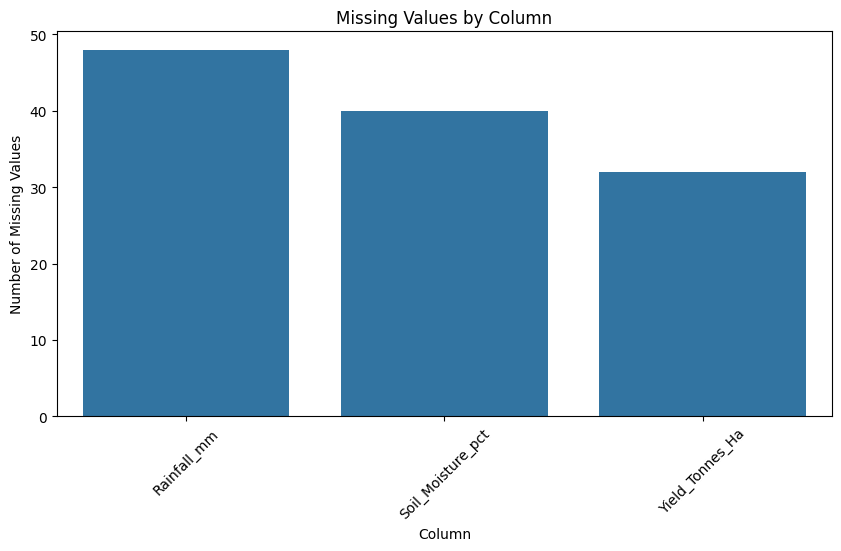

In [16]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_table.index,
    y=missing_table['Missing Values']
)

plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)

plt.show()

#**13. Duplicate analysis**

In [17]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


#**14. Descriptive statistics**


In [18]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


#**15. Categorical descriptive analysis**

In [19]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\n" + "="*50)
    print(column)
    print("="*50)
    print(df[column].value_counts())


Farm_ID
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
          ..
SF10005    1
SF10004    1
SF10003    1
SF10002    1
SF10001    1
Name: count, Length: 4000, dtype: int64

State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count,

#**16. Explore seasons**

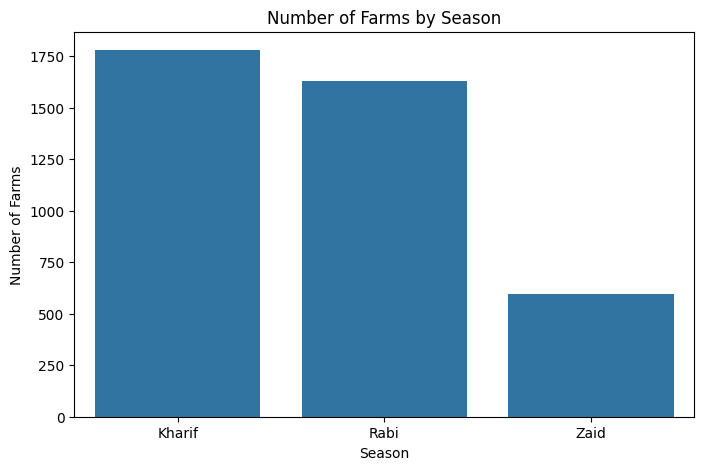

In [20]:
season_counts = df['Season'].value_counts()

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Season')

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

#**17. Explore crops**

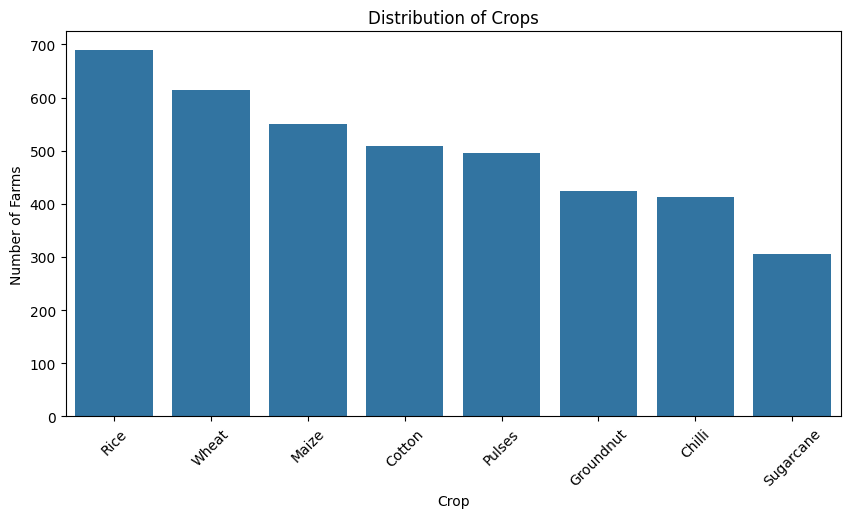

In [21]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Crop',
    order=df['Crop'].value_counts().index
)

plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)

plt.show()

#**18. Explore irrigation methods**

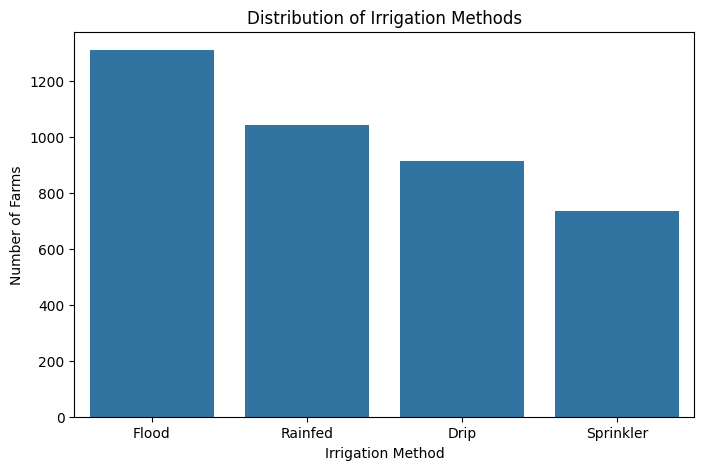

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Irrigation_Method',
    order=df['Irrigation_Method'].value_counts().index
)

plt.title('Distribution of Irrigation Methods')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Farms')

plt.show()

#**19. Data Cleaning**

In [24]:
df_clean = df.copy()

In [25]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns

for column in numeric_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

print("Missing values after cleaning:")
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after cleaning:


,0


#**20. Verify duplicates after cleaning**

In [26]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


#**21. Check cleaned dataset**

In [27]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

#**22. Outlier Analysis**

In [28]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns

print(numeric_columns.tolist())

['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [29]:
outlier_summary = []

for column in numeric_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Outlier Count': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(
    outlier_df.sort_values(
        'Outlier Count',
        ascending=False
    )
)

,Column,Q1,Q3,IQR,Outlier Count
18,Profit_INR,-148731.750,216187.75000,364919.50000,404
14,Production_Tonnes,5.020,24.35500,19.33500,333
20,Water_Efficiency_t_per_1000m3,1.661,5.15025,3.48925,322
13,Yield_Tonnes_Ha,1.050,2.83000,1.78000,302
19,Water_Used_m3,2268.750,7829.75000,5561.00000,276
17,Revenue_INR,207517.250,836874.75000,629357.50000,240
9,Potassium_kg_ha,86.200,123.60000,37.40000,32
4,Sunlight_Hours_Day,6.600,8.10000,1.50000,26
8,Phosphorus_kg_ha,46.200,69.40000,23.20000,16
10,Fertilizer_kg_ha,143.975,227.20000,83.22500,15


#**23. Boxplot**

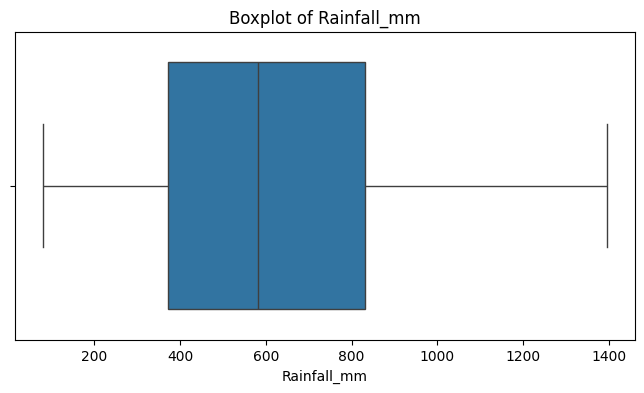

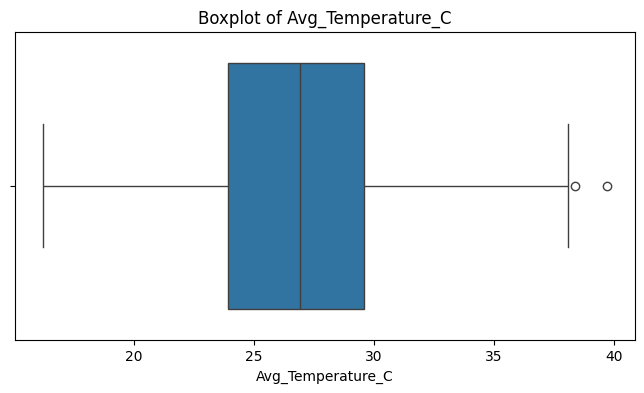

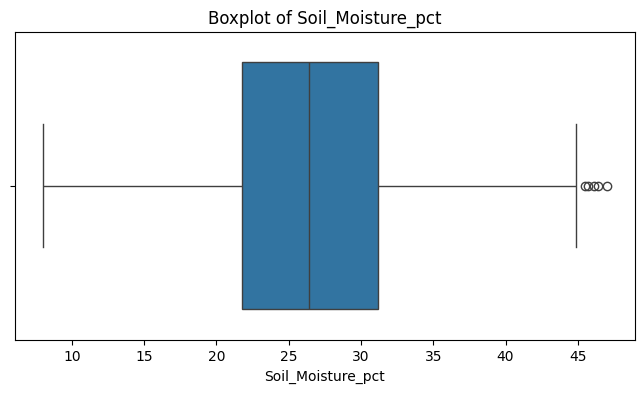

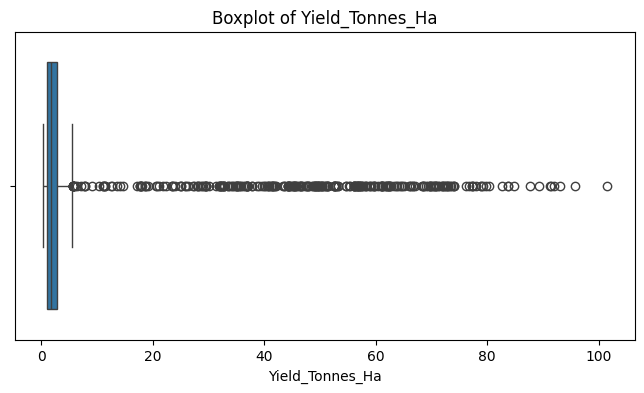

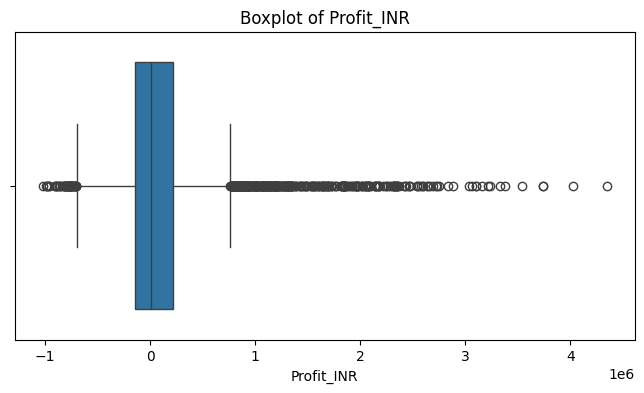

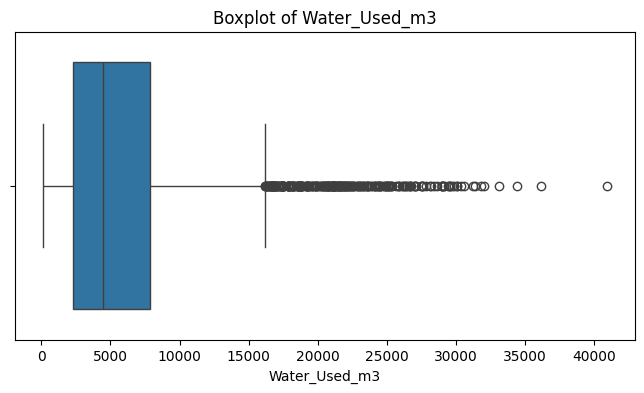

In [30]:
important_variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Used_m3'
]

for column in important_variables:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df_clean[column])

    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

    plt.show()

#**24. Univariate Analysis**


###Yeild distribution

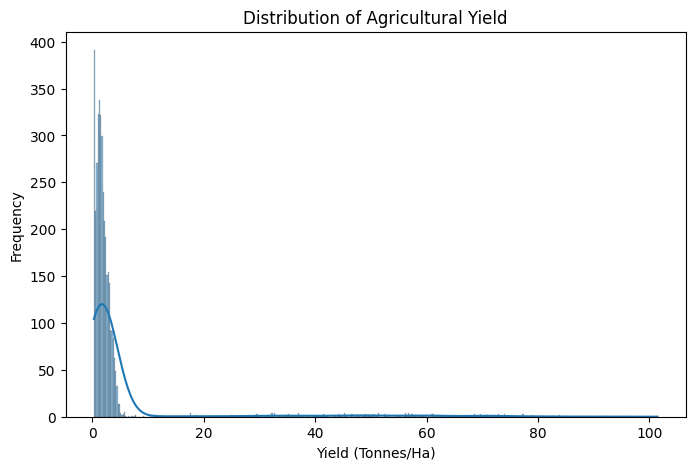

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x='Yield_Tonnes_Ha',
    kde=True
)

plt.title('Distribution of Agricultural Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')

plt.show()

###Profit Distribution

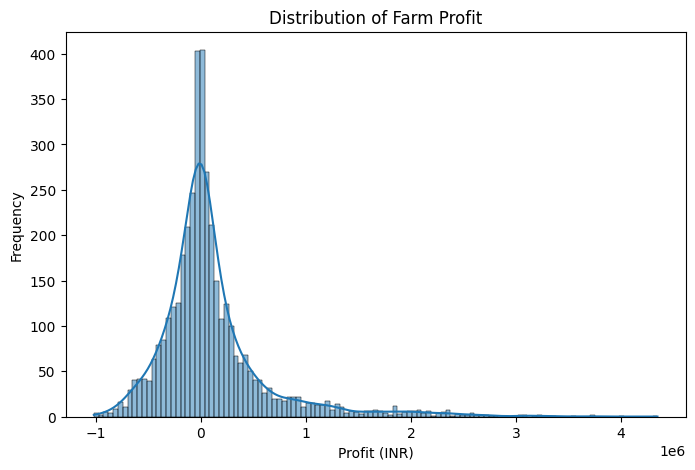

In [32]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x='Profit_INR',
    kde=True
)

plt.title('Distribution of Farm Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')

plt.show()

###Rainfall distribution

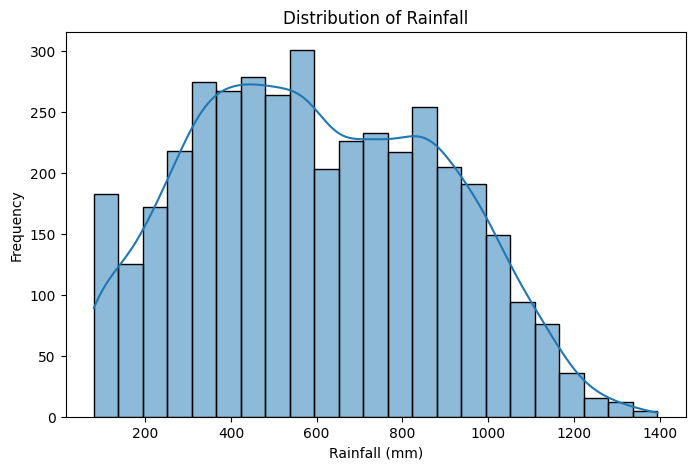

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x='Rainfall_mm',
    kde=True
)

plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')

plt.show()

#**25.Categorical univariate analysis**

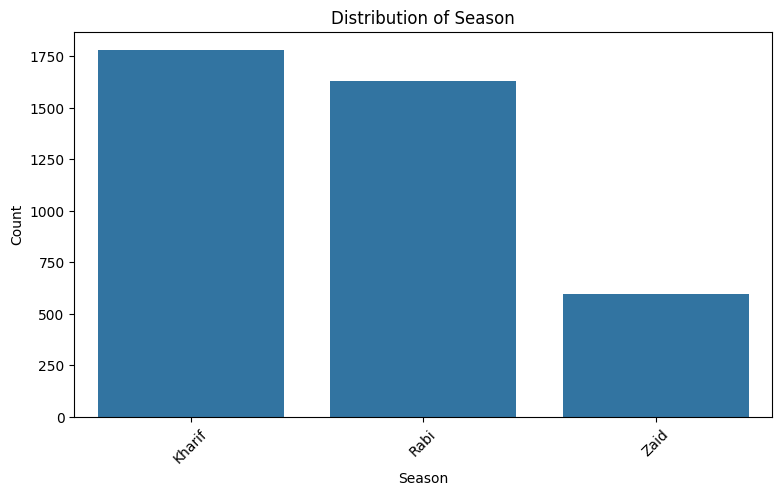

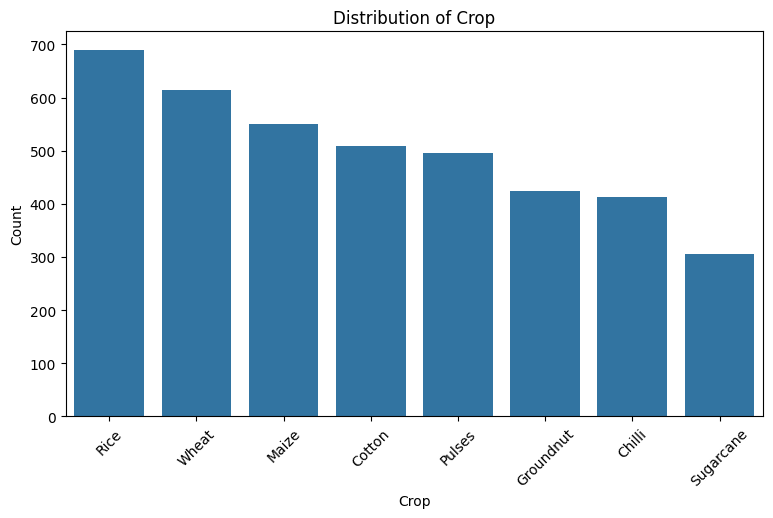

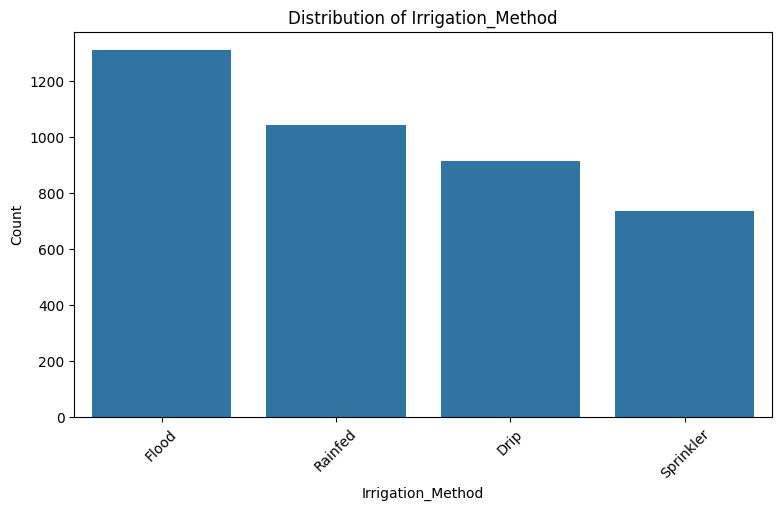

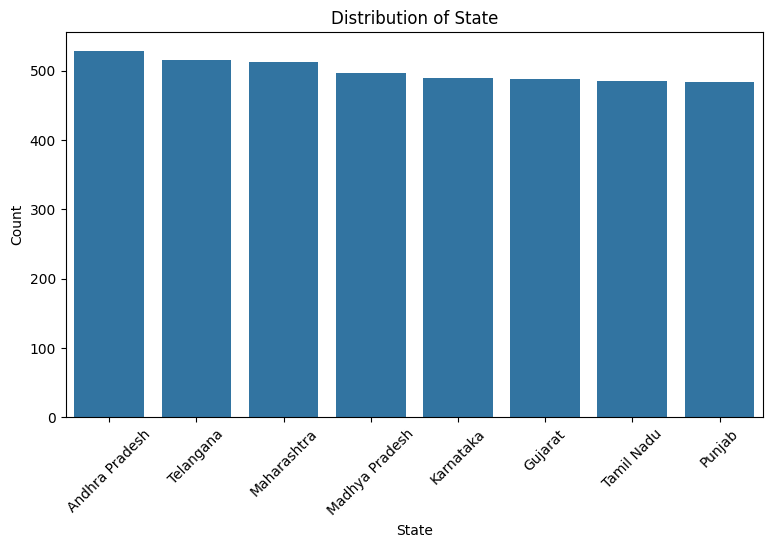

In [34]:
categorical_vars = [
    'Season',
    'Crop',
    'Irrigation_Method',
    'State'
]

for column in categorical_vars:

    plt.figure(figsize=(9, 5))

    order = df_clean[column].value_counts().index

    sns.countplot(
        data=df_clean,
        x=column,
        order=order
    )

    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')

    plt.xticks(rotation=45)

    plt.show()

#**26. Bivariate Analysis**

###Season vs Yield

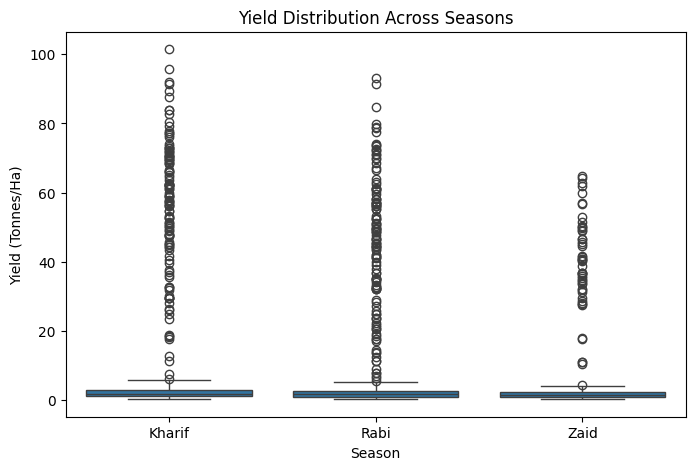

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [37]:
season_yield = (
    df_clean
    .groupby('Season')['Yield_Tonnes_Ha']
    .agg(['mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
)

display(season_yield)

,mean,median,std
Season,,,
Kharif,5.628612,1.94,14.392742
Rabi,5.039435,1.67,12.751545
Zaid,4.641313,1.46,11.273088


###Season vs Profit

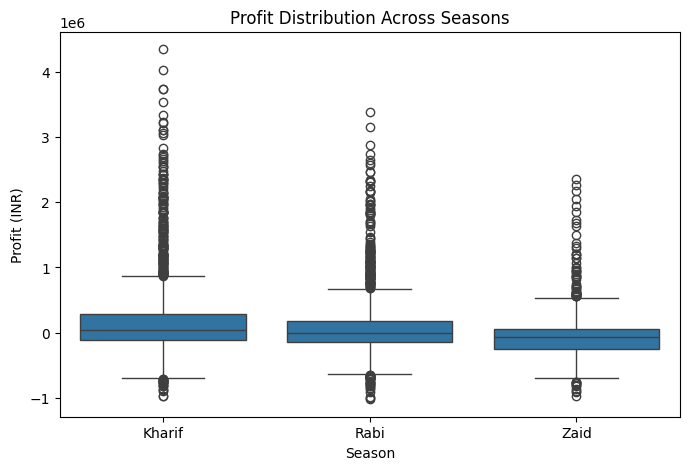

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Profit_INR'
)

plt.title('Profit Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.show()

In [38]:
df_clean.groupby('Season')['Profit_INR'].mean().sort_values(
    ascending=False
)

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


###Crop vs Yield

In [39]:
crop_yield = (
    df_clean
    .groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

display(crop_yield)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


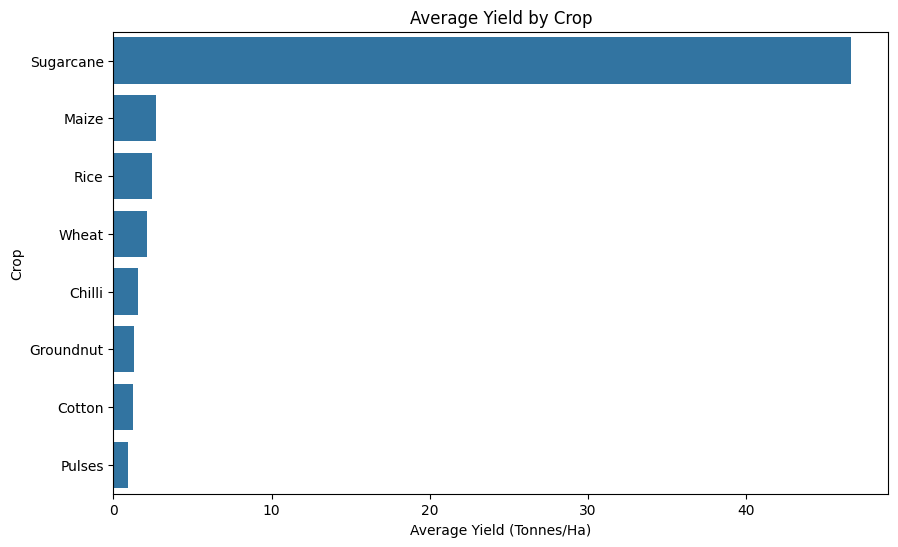

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index
)

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.show()

**An interesting observation from your dataset is that Sugarcane has a much higher yield per hectare than the other crops, so it should be interpreted separately rather than treating all crops as having comparable yield scales.**

###Rainfall vs Yield

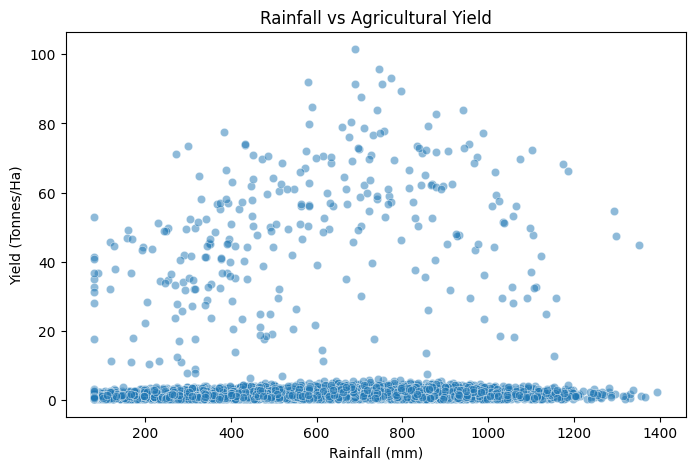

In [41]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    alpha=0.5
)

plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

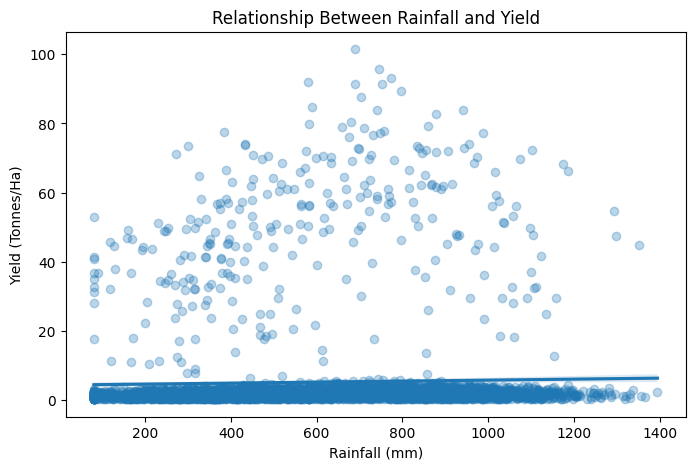

In [42]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df_clean,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.3}
)

plt.title('Relationship Between Rainfall and Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

###Temperature vs Yield

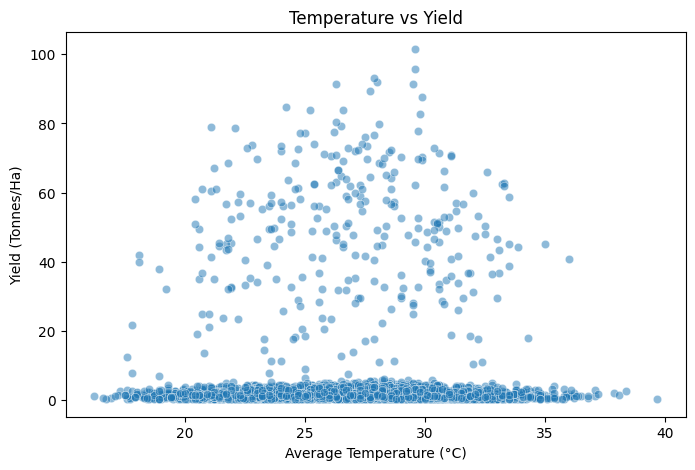

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    alpha=0.5
)

plt.title('Temperature vs Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

###Irrigation Method vs Yield

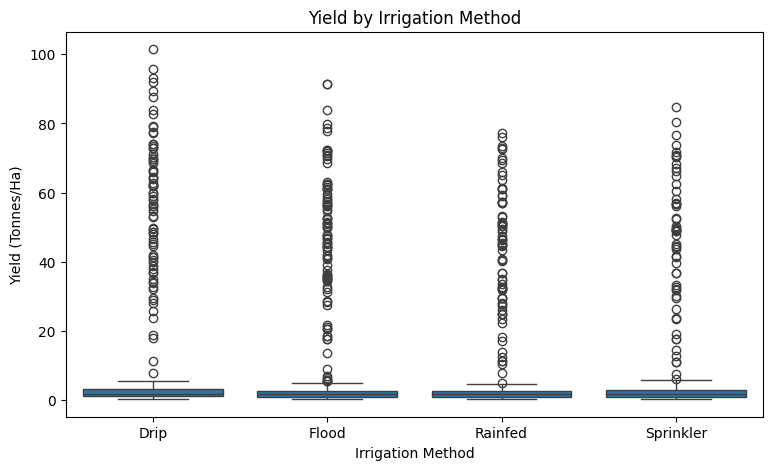

In [44]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [45]:
irrigation_yield = (
    df_clean
    .groupby('Irrigation_Method')['Yield_Tonnes_Ha']
    .agg(['mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
)

display(irrigation_yield)

,mean,median,std
Irrigation_Method,,,
Drip,6.577989,1.940,16.197016
Sprinkler,5.160627,1.785,12.810605
Flood,4.863977,1.665,12.587863
Rainfed,4.602142,1.720,11.555402


#**27. Multivariate Analysis**

###Season + Irrigation Method → Yield

In [46]:
season_irrigation = pd.pivot_table(
    df_clean,
    values='Yield_Tonnes_Ha',
    index='Season',
    columns='Irrigation_Method',
    aggfunc='mean'
)

display(season_irrigation)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,7.256296,4.977915,5.703996,4.662243
Rabi,6.111676,5.060589,3.929110,5.307235
Zaid,5.848143,3.984381,3.063786,6.135833


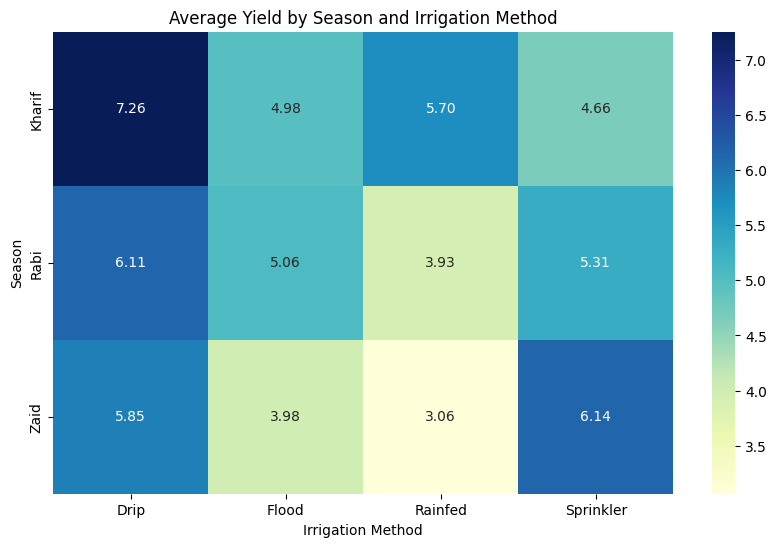

In [47]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    season_irrigation,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Yield by Season and Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Season')

plt.show()

#**28. Corelation Analysis**


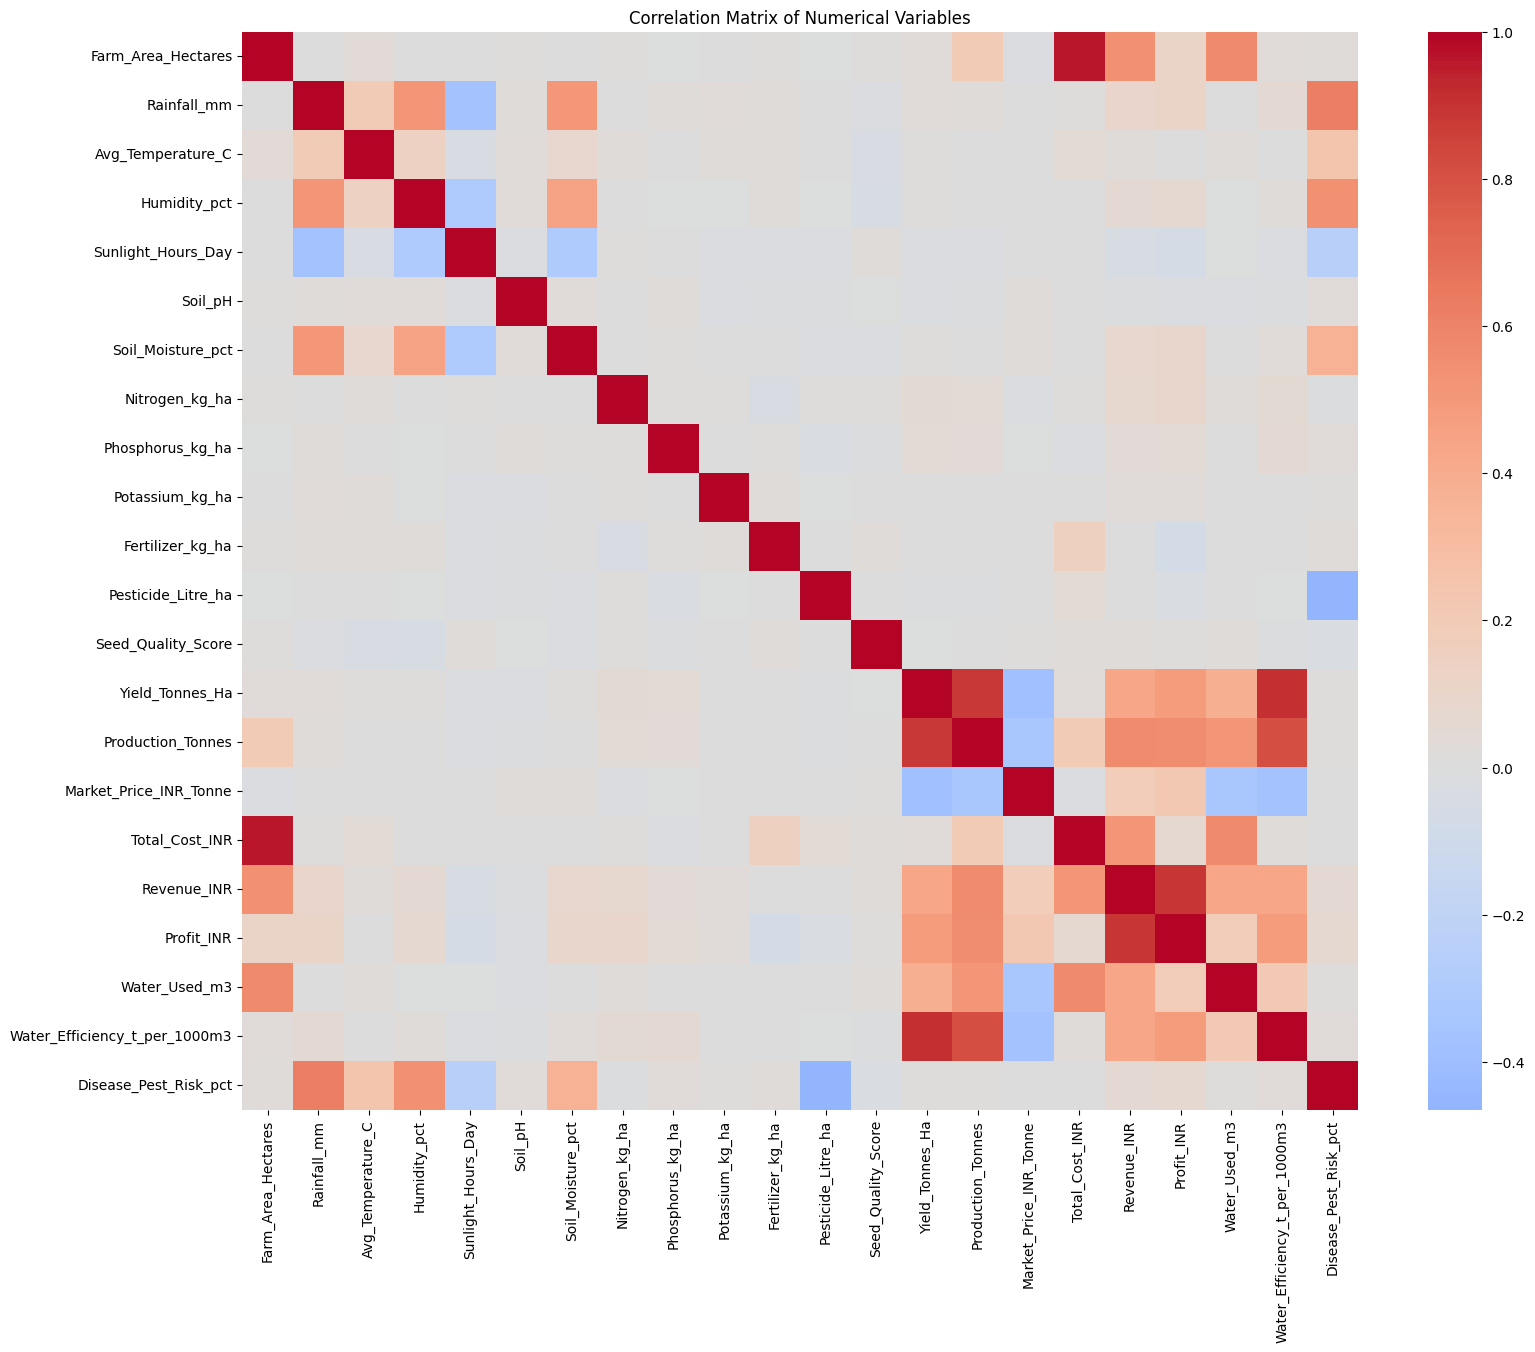

In [50]:
numeric_df = df_clean.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

###Correlation with Yield

In [51]:
yield_correlation = (
    correlation_matrix['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

display(yield_correlation)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


###Correlation of agricultural/environmental inputs with yield

In [52]:
input_variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct'
]

yield_input_corr = (
    df_clean[input_variables + ['Yield_Tonnes_Ha']]
    .corr()['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

display(yield_input_corr)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Disease_Pest_Risk_pct,0.014292
Humidity_pct,0.012297
Soil_Moisture_pct,0.010999
Avg_Temperature_C,0.009996
Potassium_kg_ha,0.003382


#**29. Seasonal comparison — core part of project**

In [53]:
season_summary = df_clean.groupby('Season').agg({
    'Farm_Area_Hectares': 'mean',
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

display(season_summary.round(2))

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,
Kharif,7.94,849.20,28.45,71.81,31.15,5.63,46.31,531804.41,710719.06,178914.65,6102.20,5.89,54.47
Rabi,7.75,437.62,23.49,57.89,24.07,5.04,41.49,513836.58,601526.05,87689.47,5846.99,5.19,40.48
Zaid,8.09,304.65,31.04,52.01,19.28,4.64,38.89,543976.73,519171.90,-24804.82,6419.89,4.41,38.22


###Seasonal yield comparison

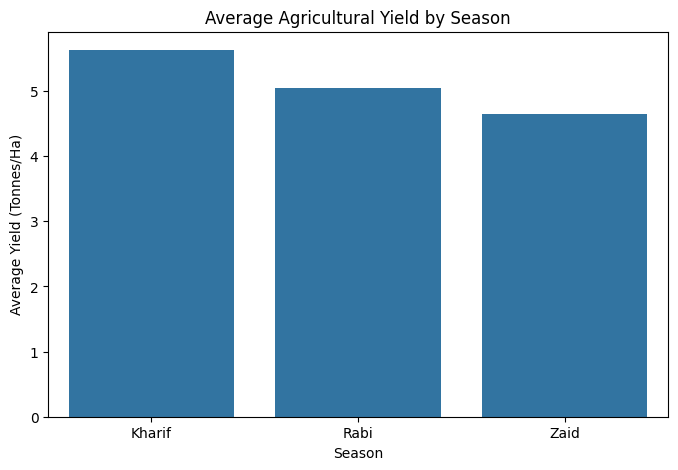

In [54]:
season_yield = (
    df_clean
    .groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

###Seasonal profit comparison

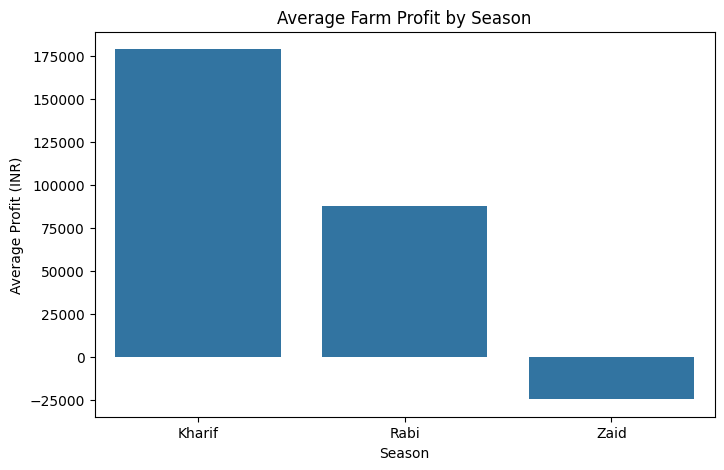

In [55]:
season_profit = (
    df_clean
    .groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title('Average Farm Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

###Seasonal disease/pest risk

In [56]:
season_risk = (
    df_clean
    .groupby('Season')['Disease_Pest_Risk_pct']
    .mean()
)

display(season_risk.round(2))

,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


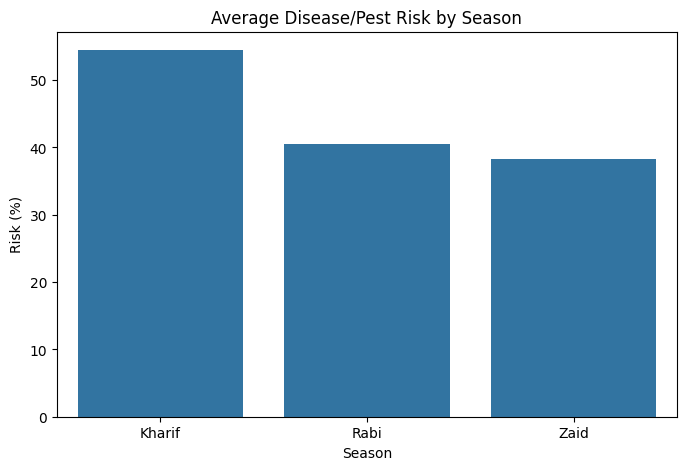

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_risk.index,
    y=season_risk.values
)

plt.title('Average Disease/Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Risk (%)')

plt.show()

#**30. Student-designed analysis 1**
### Does irrigation method influence agricultural yield?

Irrigation is an important agricultural resource. This analysis compares
average yield across different irrigation methods to identify whether
different irrigation practices are associated with differences in yield.

In [58]:
irrigation_analysis = (
    df_clean
    .groupby('Irrigation_Method')
    .agg({
        'Yield_Tonnes_Ha': ['mean', 'median'],
        'Water_Used_m3': 'mean',
        'Water_Efficiency_t_per_1000m3': 'mean',
        'Profit_INR': 'mean'
    })
)

display(irrigation_analysis.round(2))

Yield_Tonnes_Ha        Water_Used_m3  \
                             mean median          mean   
Irrigation_Method                                        
Drip                         6.58   1.94       5918.75   
Flood                        4.86   1.66       8026.47   
Rainfed                      4.60   1.72       3549.55   
Sprinkler                    5.16   1.78       6208.26   

                  Water_Efficiency_t_per_1000m3 Profit_INR  
                                           mean       mean  
Irrigation_Method                                           
Drip                                       6.27  219626.00  
Flood                                      3.44   73354.02  
Rainfed                                    7.56   79050.37  
Sprinkler                                  4.67   91121.08

#**31. Student-designed analysis 2**
###Which crop performs best in each season?

In [59]:
crop_season_yield = pd.pivot_table(
    df_clean,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

display(crop_season_yield.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


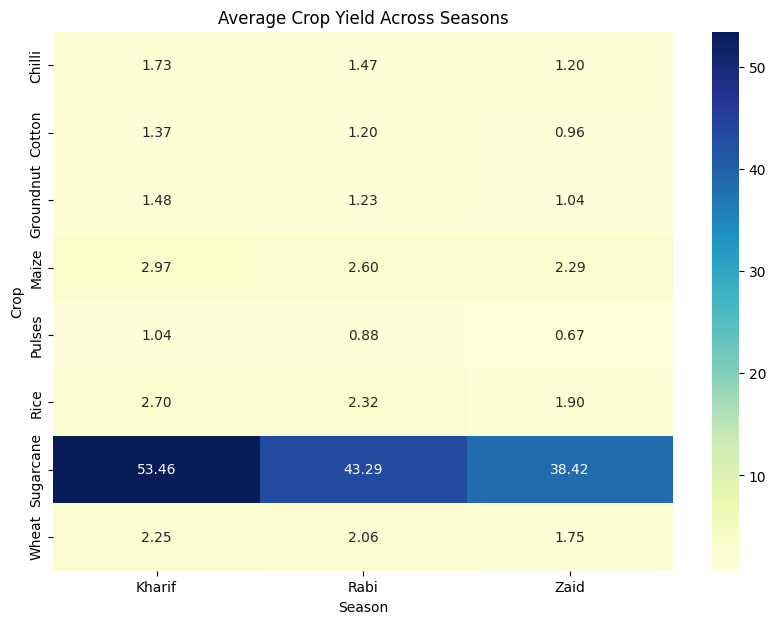

In [60]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

#**32. Student-designed analysis 3**
###Are profitable farms distributed differently across seasons?

In [61]:
df_clean['Profitability_Status'] = np.where(
    df_clean['Profit_INR'] > 0,
    'Profitable',
    'Loss'
)

display(
    df_clean['Profitability_Status'].value_counts()
)

,count
Profitability_Status,
Profitable,2034
Loss,1966


In [62]:
profitability_by_season = pd.crosstab(
    df_clean['Season'],
    df_clean['Profitability_Status'],
    normalize='index'
) * 100

display(profitability_by_season.round(2))

Profitability_Status,Loss,Profitable
Season,,
Kharif,42.21,57.79
Rabi,51.14,48.86
Zaid,64.48,35.52


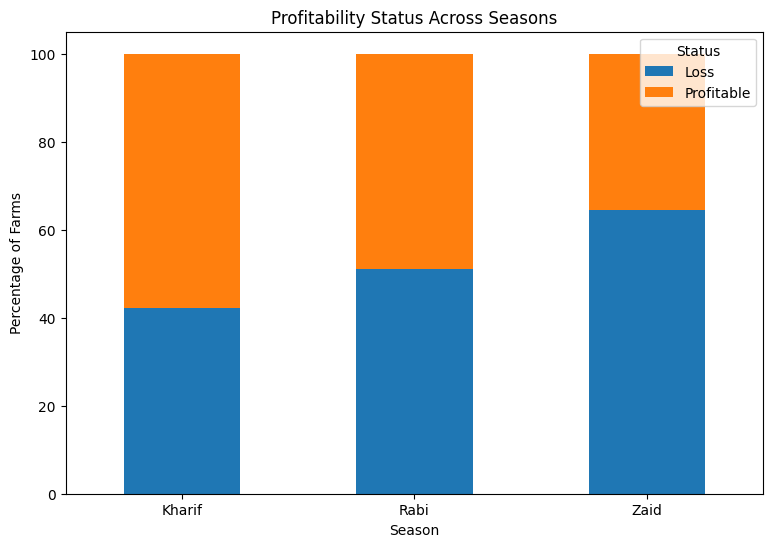

In [63]:
profitability_by_season.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6)
)

plt.title('Profitability Status Across Seasons')
plt.xlabel('Season')
plt.ylabel('Percentage of Farms')
plt.xticks(rotation=0)
plt.legend(title='Status')

plt.show()

#**33. final findings table**

In [64]:
final_findings = pd.DataFrame({
    'Analysis': [
        'Highest average yield season',
        'Highest average yield crop',
        'Highest average yield irrigation method',
        'Highest disease/pest risk season',
        'Highest percentage of profitable farms'
    ],
    'Finding': [
        df_clean.groupby('Season')['Yield_Tonnes_Ha'].mean().idxmax(),
        df_clean.groupby('Crop')['Yield_Tonnes_Ha'].mean().idxmax(),
        df_clean.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().idxmax(),
        df_clean.groupby('Season')['Disease_Pest_Risk_pct'].mean().idxmax(),
        (
            pd.crosstab(
                df_clean['Season'],
                df_clean['Profitability_Status'],
                normalize='index'
            )['Profitable']
        ).idxmax()
    ]
})

display(final_findings)

,Analysis,Finding
0,Highest average yield season,Kharif
1,Highest average yield crop,Sugarcane
2,Highest average yield irrigation method,Drip
3,Highest disease/pest risk season,Kharif
4,Highest percentage of profitable farms,Kharif


#**34. Key Findings**


Based on the analysis of the dataset, the following major observations were identified:

1. Agricultural yield varies across seasons, with Kharif showing the highest
   average yield among the three seasons.

2. Crop-level performance differs considerably, with Sugarcane showing a
   substantially higher average yield per hectare than the other crops.

3. Different irrigation methods are associated with different levels of
   agricultural yield.

4. Kharif shows the highest average disease/pest risk among the seasons.

5. The proportion of profitable farms varies across seasons, with Kharif
   showing the highest proportion of profitable farms.

6. Agricultural performance also varies across crops, states and irrigation
   methods.

7. Correlation analysis indicates relationships among agricultural,
   environmental, resource and economic variables. However, correlation
   should not be interpreted as proof of causation.

#**35. Final conclusion**

This project analyzed seasonal agricultural performance using data related
to crops, farming conditions, environmental factors, resource usage,
production and economic outcomes.

The analysis identified meaningful differences in yield, profitability,
water usage and disease/pest risk across seasons. Relationships between
agricultural variables were also examined using visualization and correlation
analysis.

The results demonstrate that agricultural performance is influenced by
multiple interacting factors and that seasonal analysis can provide useful
evidence for agricultural planning.

Overall, the analysis provides a data-driven understanding of seasonal
agricultural performance and highlights areas that can be investigated
further for improved agricultural planning and resource management.